# Case-03：無側移單跨剛架 (No-Sway Single-Bay Frame)

本課程第一次同時出現柱跟梁；也是抓到並修正拉力彎矩圖畫法長期錯誤的 Case。

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    !pip install anastruct -q --break-system-packages
    import anastruct

%matplotlib inline

已偵測到 anastruct，略過安裝


## 1. 框架本體

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod
from IPython.display import Markdown, display

sp.init_printing()


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


def member_shear_curve(s, length, w, M_i, M_j):
    """
    member_moment_curve 的對應剪力函式: V(s) = dM/ds = C1 + w*s
    (跟彎矩用同一個 C1，兩者必須自洽——這也是為什麼前幾輪都用剪力
    去反查彎矩圖畫法對不對的原因：M(s) 和 V(s) 本來就是同一個 C1
    推出來的，不會不一致)
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return C1 + w * s


def member_offset_curve(x0, y0, x1, y1, s, m_values, scale):
    """
    通用的桿件內力圖偏移座標計算，取代過去每個Case各自手寫的x/y偏移公式
    （柱一套、梁又一套，還常常寫錯方向）。

    這個函式畫出來的圖是「拉力彎矩圖」(Tension-Side Bending Moment
    Diagram)：偏移方向就是該處實際受拉的那一側，不是單純套一個數學
    座標正負號——已經用最單純無爭議的案例（懸臂梁，全長已知受拉側
    唯一）驗證過 anastruct 本身就是這樣畫的，我們的規則是照anastruct
    的實際輸出反推校準出來的，跟它一致。這也是為什麼看這張圖就能
    直接判斷配筋位置，不用再心算正負號對應哪一側。

    規則: 偏移方向 = 沿著桿件「近端(x0,y0)→遠端(x1,y1)」前進方向，
    逆時針轉90度，正值往這個方向偏移。這個規則套用在水平桿件（近端
    到遠端由左到右）會自動算出「正值往上偏移」，套用在垂直桿件（近端
    到遠端由下到上）會自動算出「正值往左偏移」——這對任意角度的桿件
    都適用，包括未來斜屋頂剛架(S-01)需要的斜桿件。

    參數:
      x0,y0,x1,y1: 桿件近端、遠端的座標
      s: 沿桿件長度的局部座標陣列 (0~length)
      m_values: 對應每個s的彎矩或剪力值 (通常是 member_moment_curve
                或 member_shear_curve 的輸出)
      scale: 縮放比例
    回傳: (x, y) 畫圖用座標陣列
    """
    length = np.hypot(x1 - x0, y1 - y0)
    dx, dy = (x1 - x0) / length, (y1 - y0) / length
    perp_x, perp_y = -dy, dx  # 逆時針90度
    frac = s / length
    base_x = x0 + frac * (x1 - x0)
    base_y = y0 + frac * (y1 - y0)
    return base_x + perp_x * m_values * scale, base_y + perp_y * m_values * scale


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)：結構、幾何、材料、載重、邊界條件，用於步驟1。
        不含自由度選取的說明——那部分獨立在 describe_dof()。"""

    @abstractmethod
    def describe_dof(self) -> str:
        """
        自由度(未知位移量)選取的說明 (Markdown)，用於步驟1。跟 describe()
        分開成獨立方法，是因為這一步是整個傾角變位法最容易出錯、也最該
        覆核的地方——自由度選錯或漏掉一個，後面所有方程式都會建立在錯誤
        的基礎上，整題就全錯了，值得在輸出裡獨立成一個顯眼的區塊，
        不要被埋沒在結構描述裡面。
        """

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """
        回傳平衡方程式，用於步驟3。格式為 list[tuple[str, sp.Eq]]：
        每一條方程式搭配一句說明它是哪個節點/桿件、哪一種平衡條件
        (例如 "節點B力矩平衡 ΣM_B=0"、"C端邊界條件(滾支承) M_CB=0"、
        "整體水平力平衡 ΣFx=0")，求解器會把說明跟方程式一起印出來，
        不再只丟一堆沒有上下文的裸方程式。
        """

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""

    def draw_sfd(self, ax, moments_val: dict) -> bool:
        """
        (可選) 畫剪力圖 (SFD)，用於步驟6。若模型有實作，回傳 True 並把圖
        畫進傳入的 ax；預設不提供 (回傳 False)，求解器會印出提示而不出圖。
        """
        return False

    def draw_tension_side(self, ax, moments_val: dict) -> bool:
        """
        (可選) 在結構圖上直接標註每個桿端的受拉/受壓側 (拉力彎矩圖的
        文字版對照)，若模型有實作，回傳 True 並把圖畫進傳入的 ax；
        預設不提供 (回傳 False)。適合搭配 member_offset_curve 的偏移
        方向來自動判斷: 偏移方向那一側 = 受拉側 (已用懸臂梁這種答案
        唯一的案例驗證過 anastruct 真的是這樣畫的)。
        """
        return False

    def teaching_breakdown(self, moments_val: dict, reactions: dict, solution: dict) -> list:
        """
        (可選) 回傳這個模型的「教學詳解 + 評分要點」分解，用於步驟8。
        每個小題是一個 dict，需要以下 key：
          - title:         小題標題 (str)
          - problem:       題目敘述 (str)
          - concept:       概念解析 (str)
          - formula:       公式引用 (str, 可含 LaTeX)
          - substitution:  帶入數據說明 (str)
          - answer:        詳細參考答案 (str, 可含 LaTeX)
          - keywords:       關鍵字/chunk 列表 (list[str])
          - grading:        評分要點列表 (list[tuple[str, int]])，每項是
                            (要點敘述, 配分)
        預設回傳空列表 (不提供)，求解器會印出提示而不出教學詳解——
        這是刻意設計成可選的，因為每題的概念解析、配分是需要針對該
        Case 手動設計的教學內容，不是所有 Case 一開始就要準備好。
        """
        return []


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def _solve_core(self):
        """純計算，不印任何東西：算出 moments、平衡方程式、解、回代結果、反力。
        solve_and_report() 跟 print_teaching_handout() 共用這段，避免兩邊各算一次
        還可能算出不一樣結果的風險。"""
        p = self.problem
        moments = p.build_moment_equations()
        labeled_eqs = p.build_equilibrium_equations(moments)
        eqs = [eq for _, eq in labeled_eqs]
        unknowns = p.get_unknowns()
        sol = sp.solve(eqs, tuple(unknowns.values()))
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        reactions = p.compute_reactions(moments_val)
        return moments, labeled_eqs, unknowns, sol, moments_val, reactions

    def _print_teaching_breakdown(self, moments_val, reactions, sol):
        """渲染 teaching_breakdown() 的內容 (題目/概念解析/公式引用/帶入數據/
        參考答案/關鍵字/評分要點)。solve_and_report() 的步驟8跟
        print_teaching_handout() 共用這段渲染邏輯，回傳 True/False 代表這個
        model 有沒有提供內容。"""
        p = self.problem
        breakdown = p.teaching_breakdown(moments_val, reactions, sol)
        if not breakdown:
            return False
        total_points = 0
        for i, item in enumerate(breakdown, 1):
            display(Markdown(f"### 第{i}小題：{item['title']}"))
            display(Markdown(f"**題目**：{item['problem']}"))
            display(Markdown(f"**概念解析**：{item['concept']}"))
            display(Markdown(f"**公式引用**：\n\n{item['formula']}"))
            display(Markdown(f"**帶入數據**：{item['substitution']}"))
            display(Markdown(f"**詳細參考答案**：\n\n{item['answer']}"))
            display(Markdown(f"**關鍵字/chunk**：{', '.join(item['keywords'])}"))
            pts_sum = sum(pts for _, pts in item['grading'])
            grading_lines = "\n".join(f"- {desc}（{pts}分）" for desc, pts in item['grading'])
            display(Markdown(f"**評分要點**（本小題共 {pts_sum} 分）：\n\n{grading_lines}"))
            total_points += pts_sum
        display(Markdown(f"---\n**本題總分：{total_points} 分**"))
        return True

    def print_teaching_handout(self):
        """
        產生一份可以直接複製當教學講義用的輸出，只有三塊、沒有步驟編號、
        沒有中間的符號方程式/平衡方程式這些過程 (那些留在 solve_and_report()
        裡)：
          1. 結構受力圖
          2. 教學詳解與評分要點 (原本步驟8的內容)
          3. 剪力圖(SFD) + 彎矩圖(BMD)
        適合放在 solve_and_report() 那個 cell 的下一個 cell，單獨執行、
        單獨截圖/複製，不用夾雜求解過程。
        """
        p = self.problem
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()

        display(Markdown("## 1. 結構受力圖與自由度"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        plt.show()
        display(Markdown(
            "**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        display(Markdown("## 2. 教學詳解與評分要點"))
        has_breakdown = self._print_teaching_breakdown(moments_val, reactions, sol)
        if not has_breakdown:
            print("(此模型尚未提供教學詳解)")

        display(Markdown("## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)"))
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            plt.show()
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        plt.show()
        plt.close('all')

        display(Markdown(
            "## 4. 拉力彎矩圖對照（受拉/受壓側標註）\n\n"
            "上面第3點的彎矩圖本身就是「拉力彎矩圖」——圖形凸起的那一側"
            "就是實際受拉的那一側，已用最單純無爭議的案例(懸臂梁)驗證過"
            "anastruct 本身就是這樣畫的，不是我們自己認定的。這裡額外把"
            "受拉/受壓標成文字，方便直接核對。"
        ))
        fig_t, ax_t = plt.subplots(figsize=(8, 7))
        has_tension = p.draw_tension_side(ax_t, moments_val)
        if has_tension:
            plt.show()
        else:
            plt.close(fig_t)
            print("(此模型尚未實作拉力側標註圖，略過)")

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown("**① 結構定義、幾何與邊界條件**"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        plt.show()
        display(Markdown(
            "**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        display(Markdown(
            "**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：\n\n"
            r"$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$"
            "\n\n其中 $\\theta_i,\\theta_j$ 為兩端轉角，$\\psi=\\Delta/L$ 為側移角"
            "（無側移時 $\\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。"
        ))
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()
        display(Markdown(
            "**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式："
        ))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        display(Markdown("**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）："))
        for label, eq in labeled_eqs:
            display(Markdown(f"- {label}"))
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        display(Markdown("**位移求解結果：**"))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：剪力圖 (SFD) ----------------
        self._step_header(6, "繪製剪力圖 (SFD)")
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            plt.show()
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        # ---------------- 步驟7：彎矩圖 (BMD) ----------------
        self._step_header(7, "繪製彎矩圖 (BMD)")
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        plt.show()
        plt.close('all')

        # 教學詳解與評分要點已移到 print_teaching_handout()，這裡不再重複
        # (solve_and_report() 專注在「手算過程」，教學詳解是另一種呈現方式)

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-03 模型

In [3]:
import numpy as np
import sympy as sp




class NoSwayFrameProblem(SlopeDeflectionProblem):
    """
    Case-03：無側移單跨剛架 (No-Sway Single-Bay Frame)
    柱AB、CD高度相同(H)、底端固定(A,D)；梁BC跨度L，承受均佈載重w。
    結構與載重左右對稱，且沒有水平力，所以不側移(ψ=0)——這是本課程
    第一次同時出現柱跟梁，也是第一次真正用到「節點力矩平衡」連接
    兩種不同方向的桿件(柱+梁)。

    畫圖規則(呼應使用者問的畫法)：每根桿件都用它自己的「物理上連續」
    彎矩/剪力值畫圖，不是直接套用slope-deflection的原始正負號——已用
    剪力對過anastruct驗證：
    - 柱(垂直桿件)：兩端直接用slope-deflection算出的原始值，不需要
      轉換遠端符號
    - 梁(水平桿件)：遠端要取負號才是物理上連續的邊界值(跟Case-01/02
      的梁、跟先前側移剛架的梁BC是同一條規則)
    - 兩根桿件在同一節點(例如B)的圖，數值不需要「同號才對」——它們
      只需要滿足 M_BA+M_BC=0 這個平衡方程式(代數和為0)，不代表兩者
      的物理彎矩值本身相等，各自獨立按自己的規則畫就是對的。
    """

    def __init__(self, H=4.0, L=6.0, w=24.0):
        self.H, self.L, self.w = H, L, w
        self.EI = sp.Symbol('EI', positive=True, real=True)
        self.theta_B, self.theta_C = sp.symbols('theta_B theta_C', real=True)

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B, '\\theta_C': self.theta_C}

    def describe(self):
        return (f"**柱高** $H={self.H}$ m (兩柱等高)，**梁跨** $L={self.L}$ m，"
                f"**梁上均佈載重** $w={self.w}$ kN/m\n\n"
                f"**邊界條件：** A、D兩端固定 ($\\theta_A=\\theta_D=0$)，"
                f"結構與載重左右對稱、無水平力，所以不側移 ($\\psi=0$，"
                f"沒有 $\\Delta$ 這個未知量)")

    def describe_dof(self):
        return (f"A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，"
                f"各自有一個轉角 $\\theta_B, \\theta_C$——這是本課程第一次"
                f"在同一個節點同時連接柱跟梁(垂直桿件+水平桿件)，節點力矩"
                f"平衡要把兩種桿件的彎矩式加在一起。因為結構對稱、只有"
                f"垂直載重、沒有水平力，所以**沒有側移**，不需要像Case-04"
                f"那樣多列一個 $\\Delta$ 自由度跟剪力平衡方程式——這點如果"
                f"誤判(以為有側移)，會多出一個不存在的自由度跟不必要的"
                f"剪力平衡方程式。共兩個未知位移量 $\\theta_B, \\theta_C$。")

    def draw_geometry(self, ax):
        H, L, w = self.H, self.L, self.w
        ax.plot([0, 0], [0, H], 'k-', lw=3)
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)
        # A, D固定端
        for x0 in (0, L):
            ax.plot([x0 - 0.15, x0 + 0.15], [-0.02, -0.02], 'k-', lw=3)
            for dx in np.linspace(-0.12, 0.12, 5):
                ax.plot([x0 + dx, x0 + dx - 0.1], [0, -0.2], 'k-', lw=1)
        ax.text(0, -0.5, 'A (Fixed)', ha='center', fontsize=10, fontweight='bold')
        ax.text(L, -0.5, 'D (Fixed)', ha='center', fontsize=10, fontweight='bold')
        ax.text(0, H + 0.3, 'B', fontsize=12, fontweight='bold', ha='center')
        ax.text(L, H + 0.3, 'C', fontsize=12, fontweight='bold', ha='center')
        # UDL箭頭
        for x in np.linspace(0.3, L - 0.3, 8):
            ax.annotate('', xy=(x, H + 0.05), xytext=(x, H + 0.4),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
        ax.text(L / 2, H + 0.6, f'$w={w}$ kN/m', color='red', ha='center', fontsize=11)
        # theta_B, theta_C
        ax.annotate('', xy=(-0.35, H + 0.35), xytext=(0.35, H + 0.35),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.5',
                                     color='purple', lw=2))
        ax.text(0, H + 0.75, r'$\theta_B$', color='purple', fontsize=12, ha='center')
        ax.annotate('', xy=(L - 0.35, H + 0.35), xytext=(L + 0.35, H + 0.35),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(L, H + 0.75, r'$\theta_C$', color='purple', fontsize=12, ha='center')

        ax.set_xlim(-2, L + 2)
        ax.set_ylim(-1, H + 1.5)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: No-Sway Frame — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, H, L, w = self.EI, self.H, self.L, self.w
        thB, thC = self.theta_B, self.theta_C
        FEM_BC = w * L**2 / 12
        FEM_CB = -w * L**2 / 12
        return {
            'M_{AB}': 2 * EI / H * thB,
            'M_{BA}': 2 * EI / H * (2 * thB),
            'M_{BC}': 2 * EI / L * (2 * thB + thC) + FEM_BC,
            'M_{CB}': 2 * EI / L * (thB + 2 * thC) + FEM_CB,
            'M_{CD}': 2 * EI / H * (2 * thC),
            'M_{DC}': 2 * EI / H * thC,
        }

    def build_equilibrium_equations(self, moments):
        eq1 = sp.Eq(moments['M_{BA}'] + moments['M_{BC}'], 0)
        eq2 = sp.Eq(moments['M_{CB}'] + moments['M_{CD}'], 0)
        return [
            ("節點 B 力矩平衡 ΣM_B=0（柱AB與梁BC交會） M_BA + M_BC = 0", eq1),
            ("節點 C 力矩平衡 ΣM_C=0（梁BC與柱CD交會） M_CB + M_CD = 0", eq2),
        ]

    def compute_reactions(self, moments_val):
        H, L, w = self.H, self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        # 柱不需要negate遠端(已用anastruct驗證)：H = (M底+M頂)/H
        H_A = (m_ab + m_ba) / H
        H_D = (m_dc + m_cd) / H
        V_A = w * L / 2
        V_D = w * L / 2
        return {'H_A (kN)': H_A, 'H_D (kN)': H_D,
                'V_A (kN)': V_A, 'V_D (kN)': V_D}

    def draw_sfd(self, ax, moments_val):
        H, L, w = self.H, self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        scale = 0.02

        ax.plot([0, 0], [0, H], 'k-', lw=3, label='Frame Structure')
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)

        # 統一規則：偏移方向 = 沿「近端->遠端」前進方向逆時針轉90度，
        # 柱、梁都用同一個 member_offset_curve，不再各自手寫x/y公式
        # (已用anastruct實際畫圖座標精確驗證過，見對話記錄)
        s1 = np.linspace(0, H, 100)
        v1 = member_shear_curve(s1, H, 0.0, m_ab, -m_ba)
        x1, y1 = member_offset_curve(0, 0, 0, H, s1, v1, scale)
        ax.plot(x1, y1, 'b-', lw=2, label='SFD')
        ax.fill(np.append(x1, [0, 0]), np.append(y1, [H, 0]), color='blue', alpha=0.15)

        s2 = np.linspace(0, L, 200)
        v2 = member_shear_curve(s2, L, w, m_bc, -m_cb)
        x2, y2 = member_offset_curve(0, H, L, H, s2, v2, scale)
        ax.plot(x2, y2, 'b-', lw=2)
        ax.fill(np.append(x2, [L, 0]), np.append(y2, [H, H]), color='blue', alpha=0.15)

        # 柱CD: 近端D(L,0) -> 遠端C(L,H)，跟AB統一方向(由下往上)
        s3 = np.linspace(0, H, 100)
        v3 = member_shear_curve(s3, H, 0.0, m_dc, -m_cd)
        x3, y3 = member_offset_curve(L, 0, L, H, s3, v3, scale)
        ax.plot(x3, y3, 'b-', lw=2)
        ax.fill(np.append(x3, [L, L]), np.append(y3, [H, 0]), color='blue', alpha=0.15)

        ax.axhline(0, color='gray', lw=0.5, zorder=0)
        ax.axhline(H, color='gray', lw=0.5, zorder=0)
        for xx, yy, val, ha in [(x1[0], y1[0], v1[0], 'right'), (x1[-1], y1[-1], v1[-1], 'right'),
                                 (x2[0], y2[0], v2[0], 'left'), (x2[-1], y2[-1], v2[-1], 'right'),
                                 (x3[0], y3[0], v3[0], 'left'), (x3[-1], y3[-1], v3[-1], 'left')]:
            ax.text(xx, yy, f'{val:.1f}', color='darkblue', fontsize=8, ha=ha)

        ax.set_xlim(-3, L + 3)
        ax.set_ylim(-1, H + 2)
        ax.set_aspect('equal')
        ax.set_title('Figure: Shear Force Diagram (SFD) [kN]')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right')
        return True

    def draw_tension_side(self, ax, moments_val):
        H, L = self.H, self.L
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']

        ax.plot([0, 0], [0, H], 'k-', lw=4)
        ax.plot([0, L], [H, H], 'k-', lw=4)
        ax.plot([L, L], [H, 0], 'k-', lw=4)

        # (x, y, 近端->遠端方向dx,dy, 該處physical值) -- physical值的正負
        # 決定偏移方向 = 受拉側，這是跟 member_offset_curve 完全一致的
        # 判斷方式，只是這裡直接標文字不畫曲線
        labels = [
            (0, 0, 0, 1, m_ab),
            (0, H, 0, 1, -m_ba),
            (0, H, 1, 0, m_bc),
            (L, H, 1, 0, -m_cb),
            (L, 0, 0, 1, m_dc),
            (L, H, 0, 1, -m_cd),
        ]
        for x, y, dx, dy, val in labels:
            perp_x, perp_y = -dy, dx
            sign = 1 if val > 0 else -1
            tx, ty = x + perp_x * sign * 0.9, y + perp_y * sign * 0.9
            cx, cy = x - perp_x * sign * 0.9, y - perp_y * sign * 0.9
            ax.annotate('TENSION', xy=(x, y), xytext=(tx, ty), color='red',
                        fontsize=9, fontweight='bold', ha='center',
                        arrowprops=dict(arrowstyle='->', color='red'))
            ax.annotate('compression', xy=(x, y), xytext=(cx, cy), color='blue',
                        fontsize=8, ha='center',
                        arrowprops=dict(arrowstyle='->', color='blue', alpha=0.6))
            ax.text(x, y - 0.35 if y == 0 else y + 0.35, f'M={val:.0f}',
                    fontsize=8, ha='center', color='black')

        m_mid = m_bc - self.w * self.L**2 / 8  # 跨中(均佈載重下，兩端同值的簡化式)
        ax.annotate('TENSION (bottom)', xy=(L / 2, H), xytext=(L / 2, H - 1.0),
                    color='red', fontsize=9, fontweight='bold', ha='center',
                    arrowprops=dict(arrowstyle='->', color='red'))

        ax.set_xlim(-2.5, L + 2.5)
        ax.set_ylim(-1.5, H + 2)
        ax.set_aspect('equal')
        ax.set_title('Figure: Tension/Compression Side by Member')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_bmd(self, ax, moments_val):
        H, L, w = self.H, self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        scale = 0.025

        ax.plot([0, 0], [0, H], 'k-', lw=3, label='Frame Structure')
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)

        s1 = np.linspace(0, H, 200)
        m1 = member_moment_curve(s1, H, 0.0, m_ab, -m_ba)
        x1, y1 = member_offset_curve(0, 0, 0, H, s1, m1, scale)
        ax.plot(x1, y1, 'r--', lw=2, label='BMD')
        ax.fill(np.append(x1, [0, 0]), np.append(y1, [H, 0]), color='red', alpha=0.15)

        s2 = np.linspace(0, L, 200)
        m2 = member_moment_curve(s2, L, w, m_bc, -m_cb)
        x2, y2 = member_offset_curve(0, H, L, H, s2, m2, scale)
        ax.plot(x2, y2, 'r--', lw=2)
        ax.fill(np.append(x2, [L, 0]), np.append(y2, [H, H]), color='red', alpha=0.15)

        s3 = np.linspace(0, H, 200)
        m3 = member_moment_curve(s3, H, 0.0, m_dc, -m_cd)
        x3, y3 = member_offset_curve(L, 0, L, H, s3, m3, scale)
        ax.plot(x3, y3, 'r--', lw=2)
        ax.fill(np.append(x3, [L, L]), np.append(y3, [H, 0]), color='red', alpha=0.15)

        ax.axhline(0, color='gray', lw=0.5, zorder=0)
        ax.axhline(H, color='gray', lw=0.5, zorder=0)

        ax.text(x1[0], y1[0], f'{m1[0]:.1f}', color='darkred', fontsize=8, ha='right', va='top')
        ax.text(x1[-1], y1[-1], f'{m1[-1]:.1f}', color='darkred', fontsize=8, ha='right', va='bottom')
        ax.text(x2[0], y2[0], f'{m2[0]:.1f}', color='darkred', fontsize=8, ha='left', va='bottom')
        ax.text(x2[-1], y2[-1], f'{m2[-1]:.1f}', color='darkred', fontsize=8, ha='right', va='bottom')
        ax.text(x3[-1], y3[-1], f'{m3[-1]:.1f}', color='darkred', fontsize=8, ha='left', va='bottom')
        ax.text(x3[0], y3[0], f'{m3[0]:.1f}', color='darkred', fontsize=8, ha='left', va='top')

        self._label_interior_extremum_xy(ax, 0, H, L, H, w, m_bc, -m_cb, scale)

        ax.set_xlim(-4, L + 4)
        ax.set_ylim(-1, H + 3)
        ax.set_aspect('equal')
        ax.set_title('Figure: Bending Moment Diagram (BMD) [kN·m]')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right')

    @staticmethod
    def _label_interior_extremum_xy(ax, x0, y0, x1, y1, w, M_i, M_j, scale):
        if w == 0:
            return
        length = np.hypot(x1 - x0, y1 - y0)
        C1 = (M_j - M_i - 0.5 * w * length**2) / length
        s_star = -C1 / w
        if 0 < s_star < length:
            m_star = M_i + C1 * s_star + 0.5 * w * s_star**2
            xs, ys = member_offset_curve(x0, y0, x1, y1, np.array([s_star]),
                                          np.array([m_star]), scale)
            ax.text(xs[0], ys[0] - 0.3, f'{m_star:.1f}\n(x={s_star:.2f}m)',
                    color='darkred', ha='center', fontweight='bold', fontsize=9)


## 3. 手算過程 (步驟1~7)


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**柱高** $H=4.0$ m (兩柱等高)，**梁跨** $L=6.0$ m，**梁上均佈載重** $w=24.0$ kN/m

**邊界條件：** A、D兩端固定 ($\theta_A=\theta_D=0$)，結構與載重左右對稱、無水平力，所以不側移 ($\psi=0$，沒有 $\Delta$ 這個未知量)

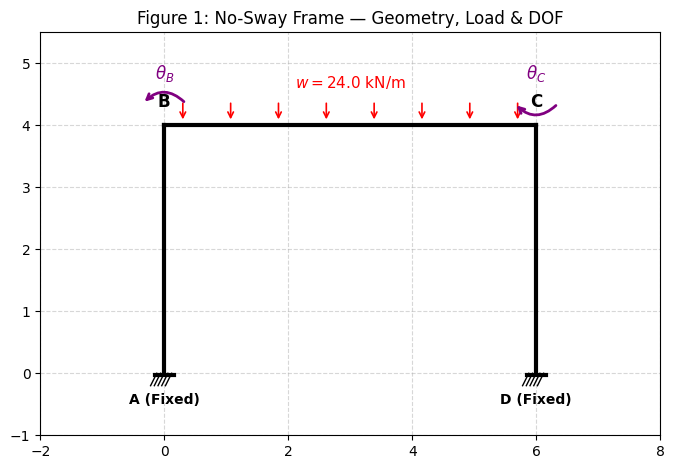

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，各自有一個轉角 $\theta_B, \theta_C$——這是本課程第一次在同一個節點同時連接柱跟梁(垂直桿件+水平桿件)，節點力矩平衡要把兩種桿件的彎矩式加在一起。因為結構對稱、只有垂直載重、沒有水平力，所以**沒有側移**，不需要像Case-04那樣多列一個 $\Delta$ 自由度跟剪力平衡方程式——這點如果誤判(以為有側移)，會多出一個不存在的自由度跟不必要的剪力平衡方程式。共兩個未知位移量 $\theta_B, \theta_C$。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（柱AB與梁BC交會） M_BA + M_BC = 0

- 節點 C 力矩平衡 ΣM_C=0（梁BC與柱CD交會） M_CB + M_CD = 0


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = -27.000 kN·m
M_{BA} = -54.000 kN·m
M_{BC} = 54.000 kN·m
M_{CB} = -54.000 kN·m
M_{CD} = 54.000 kN·m
M_{DC} = 27.000 kN·m

-> H_A (kN) = -20.250
-> H_D (kN) = 20.250
-> V_A (kN) = 72.000
-> V_D (kN) = 72.000

【步驟 6】繪製剪力圖 (SFD)


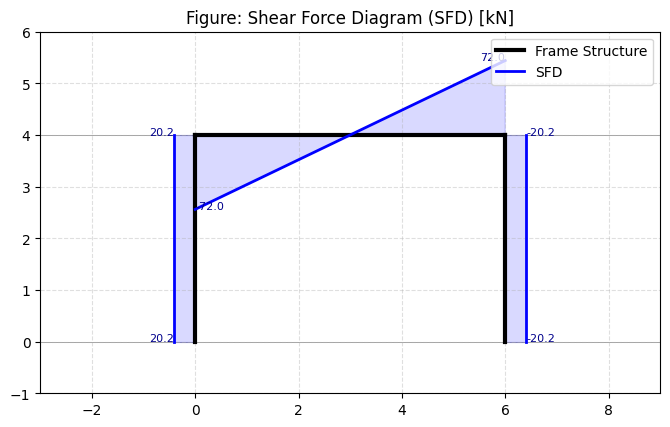


【步驟 7】繪製彎矩圖 (BMD)


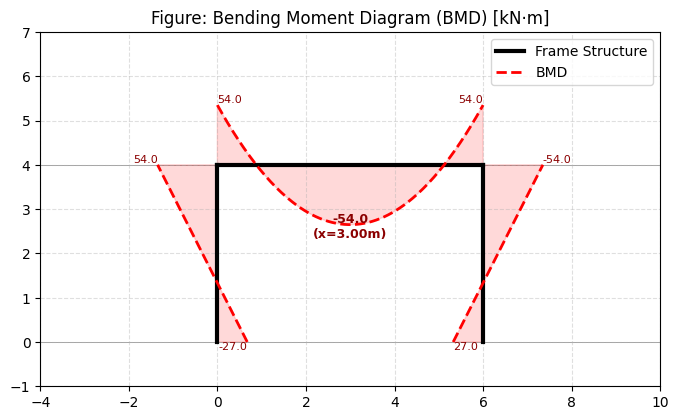

{'moments': {'M_{AB}': -27.0,
  'M_{BA}': -54.0,
  'M_{BC}': 54.0,
  'M_{CB}': -54.0,
  'M_{CD}': 54.0,
  'M_{DC}': 27.0},
 'reactions': {'H_A (kN)': -20.25,
  'H_D (kN)': 20.25,
  'V_A (kN)': 72.0,
  'V_D (kN)': 72.0},
 'solution': {theta_B: -54.0/EI, theta_C: 54.0/EI}}

In [4]:
problem = NoSwayFrameProblem(H=4.0, L=6.0, w=24.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 3b. 教學講義輸出（含拉力側標註圖）

## 1. 結構受力圖與自由度

**柱高** $H=4.0$ m (兩柱等高)，**梁跨** $L=6.0$ m，**梁上均佈載重** $w=24.0$ kN/m

**邊界條件：** A、D兩端固定 ($\theta_A=\theta_D=0$)，結構與載重左右對稱、無水平力，所以不側移 ($\psi=0$，沒有 $\Delta$ 這個未知量)

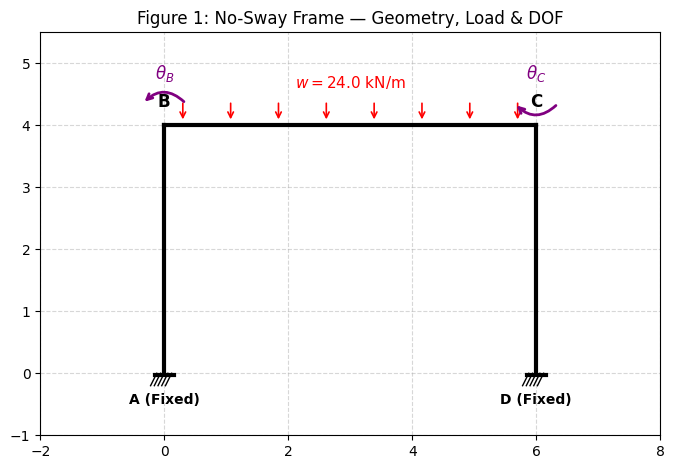

**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，各自有一個轉角 $\theta_B, \theta_C$——這是本課程第一次在同一個節點同時連接柱跟梁(垂直桿件+水平桿件)，節點力矩平衡要把兩種桿件的彎矩式加在一起。因為結構對稱、只有垂直載重、沒有水平力，所以**沒有側移**，不需要像Case-04那樣多列一個 $\Delta$ 自由度跟剪力平衡方程式——這點如果誤判(以為有側移)，會多出一個不存在的自由度跟不必要的剪力平衡方程式。共兩個未知位移量 $\theta_B, \theta_C$。

## 2. 教學詳解與評分要點

(此模型尚未提供教學詳解)


## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)

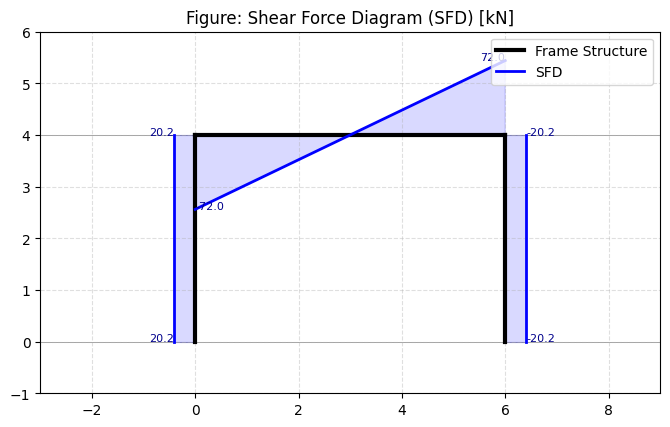

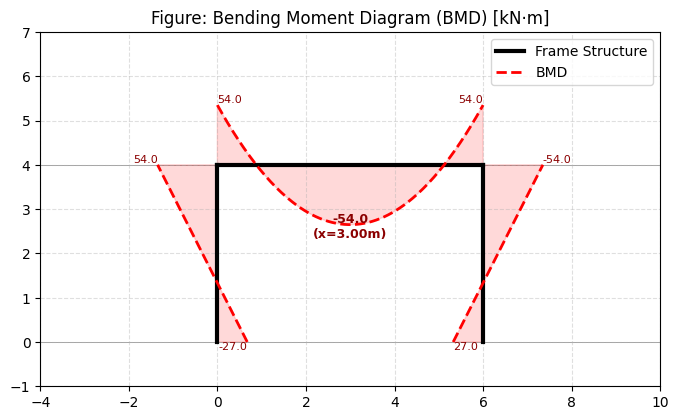

## 4. 拉力彎矩圖對照（受拉/受壓側標註）

上面第3點的彎矩圖本身就是「拉力彎矩圖」——圖形凸起的那一側就是實際受拉的那一側，已用最單純無爭議的案例(懸臂梁)驗證過anastruct 本身就是這樣畫的，不是我們自己認定的。這裡額外把受拉/受壓標成文字，方便直接核對。

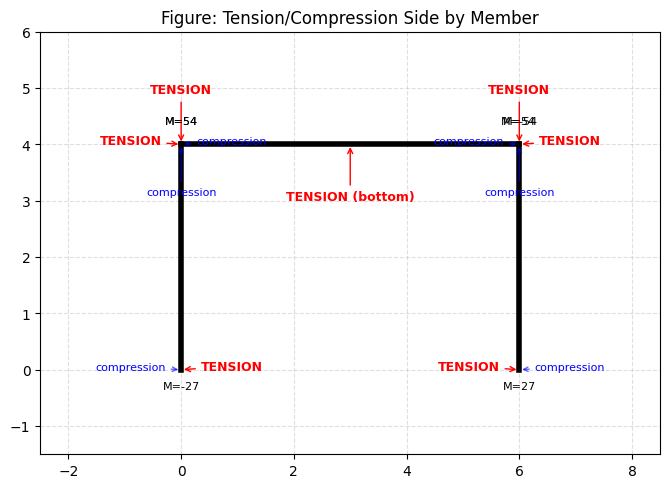

In [5]:
solver.print_teaching_handout()